# Pre-Workshop Data Analysis/Exploration 

In [3]:
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd 
import numpy as np


# Basic Python things

In [22]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])

A[1:100,1:100]



array([[5, 6],
       [8, 9]])

# Lab 1 Simple Instruction 

In [ ]:
k=0;
for i in range(1,11): 
    k=k+1/10;
    print(k)
print(k==1)

# Lab 1 Function

In [ ]:
# Hence, you must be careful in using the variable j when dealing with complex numbers. 
# What do you expect from the following operation? Can you explain what you observe?

j = 10
j = j*(-1)**(0.5)
print(j)

In [26]:
def sum1(n):
    # sum1(n) computes the sum of 1 + 2 + ... + n 
    total = 0;
    for i in range(1,n):
        total = total + i
    return total
print(sum1(2))

def sum2(n):
    # sun2(n) sums integers squared 
    total = 0;
    for i in range(1,n+1):
        total = total + i**2 
    return total

x = 10


1


# Ch 5 Exercises - PCA 

In [4]:
nchs_rows = []

with open("US1969.dat", "r", encoding="cp1252") as f:
    for x in f: 

        try: 
            birth_weight = int(x[76:78])
            mother_age = int(x[44:46])
            birth_order = int(x[62])
            month_prenatal_care = int(x[109:111])
            gestation_wks = int(x[94:96])

            nchs_rows.append([
                birth_weight,
                mother_age,
                birth_order,
                month_prenatal_care,
                gestation_wks
            ])

        except:
            continue 

    nchs_dat = np.array(nchs_rows)

print(nchs_dat.shape)

(1800103, 5)


## Normalize

In [7]:
normalized_nchs = (nchs_dat - nchs_dat.mean(axis=0)) / nchs_dat.std(axis=0)

print(normalized_nchs.shape)
print(np.mean(normalized_nchs, axis=0))

(1800103, 5)
[-9.61050017e-15 -6.76064660e-15  9.44294471e-14 -8.28458172e-13
  8.52475702e-13]


## Matrix Product 

In [6]:
# Compute the inner product of the normalized feature matrix 
nchs_prod = normalized_nchs.T @ normalized_nchs

print(nchs_prod.shape)

(5, 5)


## Eigenvalues/Eigenvectors 

In [24]:
# Compute eigenvalues and eigenvectors for the inner product of the normalized feature matrix

eigenvalues, eigenvectors = np.linalg.eig(nchs_prod)

print(eigenvalues)
print(eigenvectors)

# Sort by magnitude 
eigenvalues_sorted = sorted(eigenvalues, reverse=True)
print(eigenvalues_sorted)

eigenvectors_sorted = eigenvectors[:, np.argsort(eigenvalues)[::-1]]
print(eigenvectors_sorted)

[ 817716.57036167 1189283.19710184 1806947.03666587 2712333.34883553
 2474234.84709363]
[[-0.02434109  0.2572997  -0.94585127  0.19329677  0.03472912]
 [-0.61844991 -0.34322542  0.05799988  0.68912242 -0.14650026]
 [ 0.61736539  0.31396784  0.21002778  0.68992451 -0.01329197]
 [-0.39399471  0.55211297  0.19743859  0.05479584  0.70565916]
 [ 0.28382277 -0.64233064 -0.13750536  0.093532    0.69224275]]
[np.float64(2712333.3488355335), np.float64(2474234.8470936255), np.float64(1806947.0366658731), np.float64(1189283.1971018405), np.float64(817716.5703616659)]
[[ 0.19329677  0.03472912 -0.94585127  0.2572997  -0.02434109]
 [ 0.68912242 -0.14650026  0.05799988 -0.34322542 -0.61844991]
 [ 0.68992451 -0.01329197  0.21002778  0.31396784  0.61736539]
 [ 0.05479584  0.70565916  0.19743859  0.55211297 -0.39399471]
 [ 0.093532    0.69224275 -0.13750536 -0.64233064  0.28382277]]


## Project and Plot

In [29]:
# Project the data in the feature matrix along the eigenvectors 
# corresponding to the two largest eigenvalues
lg_eig = eigenvectors_sorted[:, :2]

projected_nchs = normalized_nchs @ lg_eig

print(projected_nchs)


# Plot each observation in this projected space according to quartile of weight at birth
projected_nchs_df = pd.DataFrame(projected_nchs, columns=["PC1", "PC2"])
projected_nchs_df["birth_weight"] = nchs_dat[:, 0] 

projected_nchs_df["bw_quartile"] = pd.qcut(
    projected_nchs_df["birth_weight"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

#print(projected_nchs_df)


[[ 1.01633174 -1.70353744]
 [-0.7825762  -1.55019546]
 [-0.39950815 -1.71879772]
 ...
 [ 0.42758696  1.44036334]
 [ 2.63462766 -0.20759748]
 [ 1.88244405  0.27255291]]


/Users/higgins/uvenv/DAIR3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


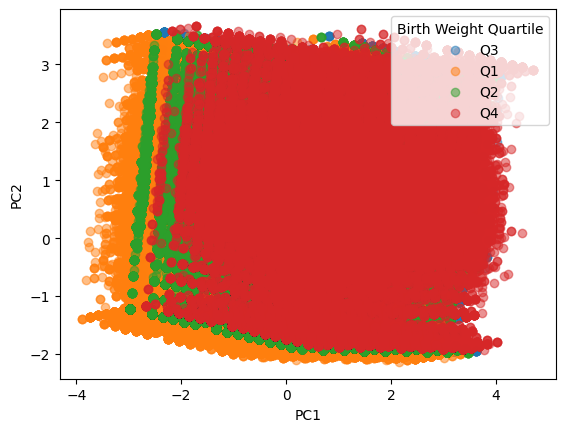

In [30]:
## from chatgpt; if time, try to do it on my own 
for q in projected_nchs_df["bw_quartile"].unique():

    subset = projected_nchs_df[
        projected_nchs_df["bw_quartile"] == q
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=q,
        alpha=0.5
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Birth Weight Quartile")
plt.show()

## Exploring data

In [2]:
#with open("US1969.dat", "r", encoding="cp1252") as f:
    #for x in f: 
        #print(x[97:99])
        #print(line, end='')
        #parsed_data = [line.split()]
        #df = pd.DataFrame(f)
        #df = df.rename(columns={0: 'year',
                                #97:99: 'mother_education'})
#print(parsed_data)
# print(df)  





## Question 28: Texas live births 1969 

In [ ]:
with open("US1969.dat", "r", encoding="cp1252") as f:
    counter = 0; 
    for x in f: 
        if (x[0] == "9" # born in 1969
            and x[12] == "4" and x[13] == "4" # specify mother residence is TX
            and x[27:29] == "44" # specify place of occurrence is TX
            #and x[51:53] == "00" # specify number of children born dead is 0
            ):
            counter = counter + 1 
print(counter)


112565


## Counting education 

In [ ]:
with open("US1969.dat", "r", encoding="cp1252") as f:
    counter = 0; 
    for x in f: 
        if (x[97:99] == "88" # how many mother education = not applicable
            ):
            counter = counter + 1 

print(counter)

# 651936 had NA for mother education 

# Education and Birth Order 

In [5]:
education = []
birth_order = []

f = open("US1969.dat", "r", encoding="cp1252")


for x in f: 
    year = int(x[0])
    education.append((x[99:101]))
    birth_order.append(int(x[59]))
    #print(year, mother_education, birth_order) 
    #print(type(mother_education))
    #print(type(birth_order))
    #break
df = pd.DataFrame({'education': education, 'birth_order': birth_order})




In [ ]:

# what type is education?
print(df['education'].dtype)

#print(df)

## Categorical Education 

In [6]:
#df['education'].value_counts()
#df['birth_order'].value_counts()

# convert education to categorical variable with labels
education_lab = {
        '00' : 'NA',
        '01' : '0-5y',
        '02' : '6y',
        '03' : '7y',
        '04' : '8y',
        '05' : '9y',
        '06' : '10y',
        '07' : '11y',
        '08' : '12y',
        '09' : '13y',
        '10' : '14y',
        '11' : '15y',
        '12' : '16y',
        '13' : '17+y',
        '14' : 'unknown'
}

df['education'] = pd.Categorical(
        df['education'].replace(education_lab),
        categories=education_lab.values(),
        ordered=True
)

#print(df)

## Describe 

In [17]:
print(df.loc[
    df['education'] == "17+y", 'birth_order'].describe())

print(df.groupby('education')['birth_order'].describe())

print(df['birth_order'].describe())

print(df['education'].describe())

count    18784.000000
mean         2.243984
std          1.638117
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: birth_order, dtype: float64
              count      mean       std  min  25%  50%  75%  max
education                                                       
NA         651936.0  2.472296  1.761850  1.0  1.0  2.0  3.0  9.0
0-5y        12143.0  4.313679  2.560264  1.0  2.0  4.0  7.0  9.0
6y           8752.0  3.855462  2.440145  1.0  2.0  3.0  6.0  9.0
7y          14501.0  3.671678  2.408231  1.0  2.0  3.0  5.0  9.0
8y          53453.0  3.537220  2.321544  1.0  2.0  3.0  5.0  9.0
9y          59845.0  3.026853  2.117464  1.0  1.0  2.0  4.0  9.0
10y         97571.0  2.936580  2.041954  1.0  1.0  2.0  4.0  9.0
11y        103620.0  2.746642  1.960229  1.0  1.0  2.0  4.0  9.0
12y        519768.0  2.525683  1.760304  1.0  1.0  2.0  3.0  9.0
13y         66327.0  2.285540  1.679671  1.0  1.0  2.0  3.0  9.0
14y       

Text(0, 0.5, 'Birth Order')

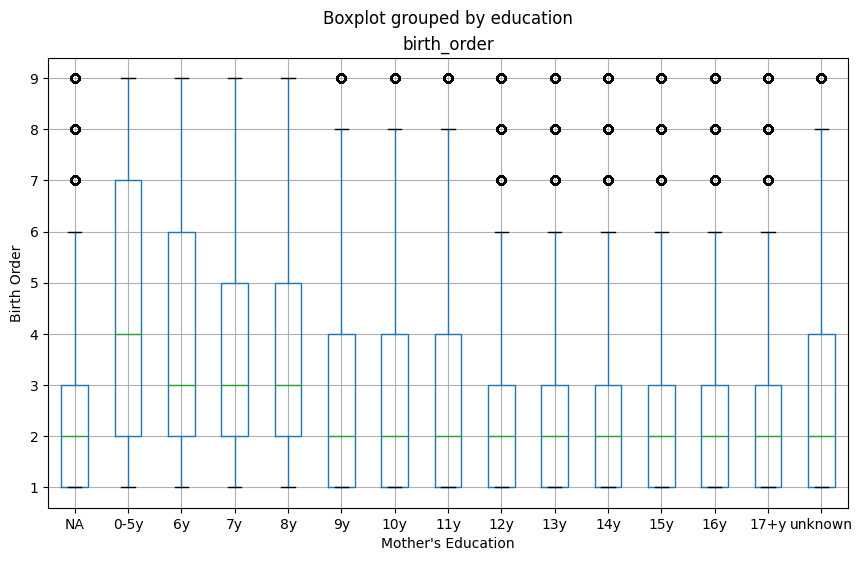

In [9]:
#import plotly.express as px

#px.bar(df, x='education', y='birth_order')

df.boxplot(column="birth_order", by="education", figsize=(10, 6))
plt.xlabel("Mother's Education")
plt.ylabel("Birth Order")

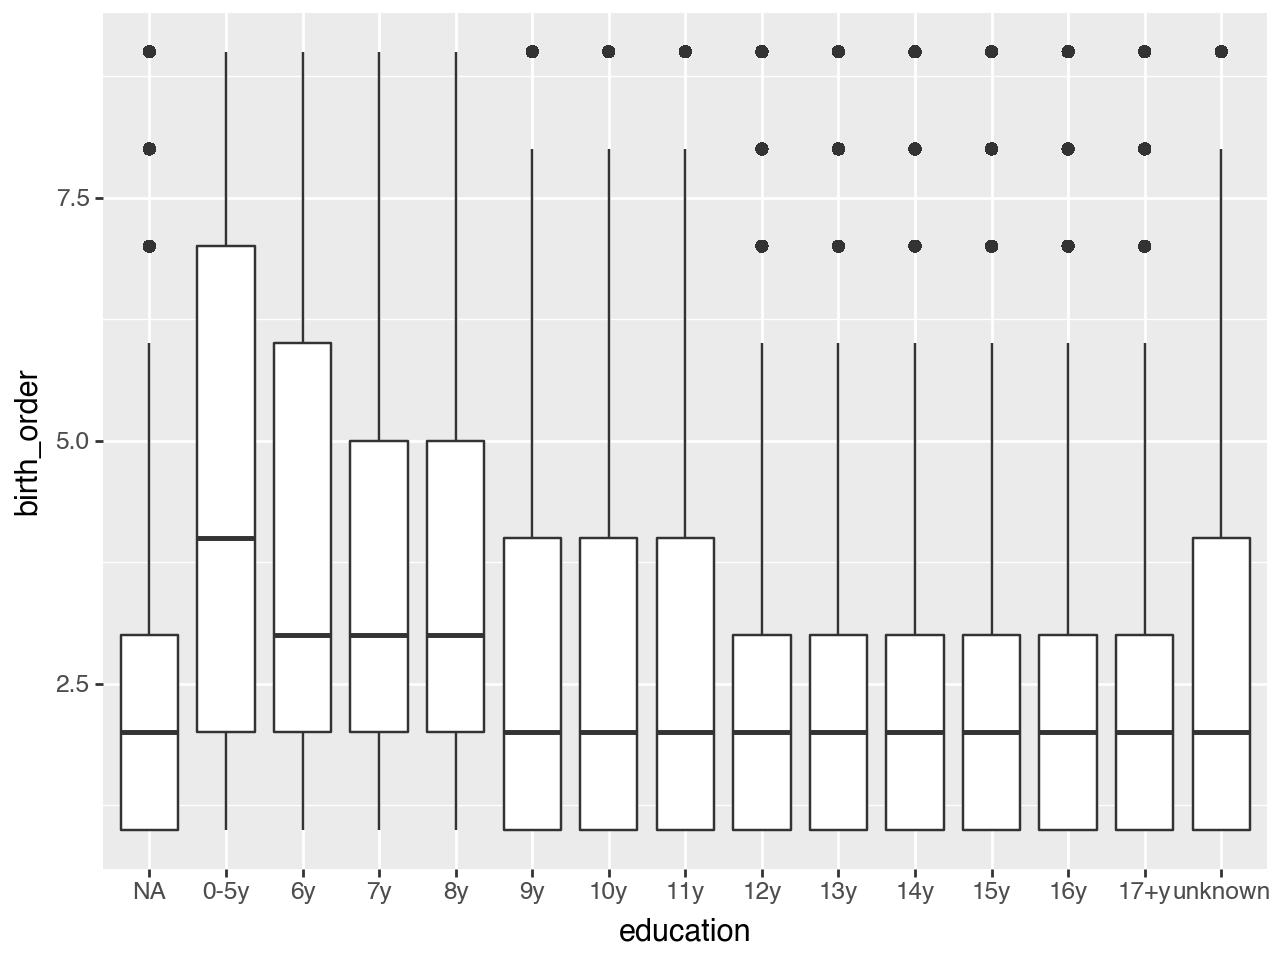

In [7]:

# ggplot style plot: 
p9.ggplot(df, p9.aes(x='education', y='birth_order')) + p9.geom_boxplot()
